# Bewley classics: a replication of Huggett (1993) and Aiyagari (1994)

**How far does uninsurable income risk push the interest rate below the rate of time preference, and do today's solvers reproduce the two tables that answered that question?**

Huggett (1993), "The risk-free rate in heterogeneous-agent incomplete-insurance economies", *Journal of Economic Dynamics and Control* 17(5-6), 953-969, and Aiyagari (1994), "Uninsured idiosyncratic risk and aggregate saving", *Quarterly Journal of Economics* 109(3), 659-684, computed stationary equilibria of economies in which households self-insure with one asset. Their tables are the targets here, transcribed from the printed pages; Aiyagari's also agree with the tables of his working paper (Federal Reserve Bank of Minneapolis Working Paper 502, revised December 1993, p. 35), which documents his method in more detail. No data are used.

| Replication card | |
|---|---|
| Results replicated | Aiyagari's Table I (the Markov chain) and Table II (24 equilibrium interest rates); Huggett's Tables 1-2 (8 equilibrium bond prices) |
| Oracles (independent of puremacro) | (1) The published tables. Table II and Huggett's tables are first checked against the identities $s=\delta\alpha/(r+\delta)$ and $r=q^{-6}-1$; Table I has no such identity and is checked by reproduction. (2) The replications behind Kirkby (2023), "Quantitative Macroeconomics: Lessons Learned from Fourteen Replications", *Computational Economics* 61, 875-896: other software (the VFI Toolkit) and another method (discretized value function iteration), stored as frozen numbers. They cover Huggett's eight prices and Aiyagari's six $\rho=0.9$ rates on a 27-state chain |
| Our solver | `solve_egm` (continuous policies), `continuous_stationary_distribution` (Young's lotteries) and a bracketing root-finder |
| Internal checks (not oracles) | Grid refinement; the packaged `solve_aiyagari_continuous` (the same method with a separately coded household solver); `VFIProblem` (discrete value function iteration, a different method) on the worst Huggett cell |
| Acceptance | Table I: equal at the printed precision. Tables II, 1 and 2: every published ordering must hold, and each cell's gap is classified against our numerical error. Kirkby: agreement within the resolution of his grids (one price step plus rounding for Huggett, two rate steps for Aiyagari) |
| Verdict | Printed by the scorecard at the end, from the computed values |

## The method in math

A household with income state $z$ and assets $a$ solves
$$\max E_0\sum_t\beta^t\frac{c_t^{1-\mu}}{1-\mu}\quad\text{s.t.}\quad c_t+a_{t+1}=(1+r)a_t+w\,z_t,\qquad a_{t+1}\ge\underline a,$$
with $z$ a finite Markov chain and $\psi$ the stationary distribution of households over $(a,z)$. **Aiyagari**: $z$ is the labor endowment $l$, $\underline a=0$, and a Cobb-Douglas firm pays $r=\alpha K^{\alpha-1}L^{1-\alpha}-\delta$ and the wage $w$, where $L=E[l]$ is effective labor. Capital clears when $\int a\,d\psi=K(r)$, the firm's demand, and the saving rate is $s=\delta\alpha/(r+\delta)$. Income follows
$$\log l_t=\rho\log l_{t-1}+\sigma(1-\rho^2)^{1/2}\epsilon_t,$$
so $\sigma$ is the unconditional standard deviation of log income, discretized by a seven-state chain. **Huggett**: an exchange economy with endowment $e\in\{0.1,1\}$ and a bond in zero net supply, $c+q\,a'=a+e$ and $a'\ge\underline a$ in bond units; $q$ clears $\int a\,d\psi=0$. With $x=q\,a$ this is the display above in $x$, with $wz=e$, $1+r=1/q$ and the price-dependent limit $x'\ge q\,\underline a$, which is how the code solves it. Huggett writes risk aversion as $\sigma$; here it is $\mu$ in both papers. With full insurance $r=1/\beta-1$.

## Intuition

**Intuition.** A household that cannot insure income risk saves for a rainy day. When every household does so, the supply of savings rises, and the interest rate must fall below the rate of time preference to clear the asset market. The effect grows with the size and persistence of the risk and with risk aversion, and it shrinks when households can borrow more. Both papers make that argument with numbers, so the numbers themselves are the replication target. They were computed in the early 1990s with simulation or coarse grids, and they rest on a discretized income process whose own accuracy is part of the result.

## Worked code

The published values are stored as printed, with Kirkby's replicated values beside them. Each household problem is solved by the endogenous grid method, which inverts the Euler equation on a grid of next-period assets and so needs no root-finding at each node (notebook 52 derives it). The stationary distribution uses Young's lotteries on a fine histogram: each policy's mass is split between the two neighbouring histogram nodes so that its mean is preserved (`docs/vfi_continuous_equilibrium.md`, section 1.2). The equilibrium price comes from Brent's method.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
from puremacro.vfi import (VFIProblem, continuous_stationary_distribution, markov_stationary,
                           rouwenhorst, solve_aiyagari_continuous, solve_egm, tauchen)

# Aiyagari (1994), Table I: (sigma, rho) -> coefficient of variation and serial correlation of the chain.
AIYAGARI_TABLE_I = {(0.2, 0.0): (0.21, 0.0), (0.2, 0.3): (0.21, 0.3), (0.2, 0.6): (0.21, 0.59),
                    (0.2, 0.9): (0.24, 0.9), (0.4, 0.0): (0.43, 0.0), (0.4, 0.3): (0.43, 0.28),
                    (0.4, 0.6): (0.44, 0.58), (0.4, 0.9): (0.49, 0.89)}
# Aiyagari (1994), Table II: (sigma, rho, mu) -> (net return to capital %, aggregate saving rate %).
AIYAGARI_TABLE_II = {
    (0.2, 0.0, 1): (4.1666, 23.67), (0.2, 0.0, 3): (4.1456, 23.71), (0.2, 0.0, 5): (4.0858, 23.83),
    (0.2, 0.3, 1): (4.1365, 23.73), (0.2, 0.3, 3): (4.0432, 23.91), (0.2, 0.3, 5): (3.9054, 24.19),
    (0.2, 0.6, 1): (4.0912, 23.82), (0.2, 0.6, 3): (3.8767, 24.25), (0.2, 0.6, 5): (3.5857, 24.86),
    (0.2, 0.9, 1): (3.9305, 24.14), (0.2, 0.9, 3): (3.2903, 25.51), (0.2, 0.9, 5): (2.5260, 27.36),
    (0.4, 0.0, 1): (4.0649, 23.87), (0.4, 0.0, 3): (3.7816, 24.44), (0.4, 0.0, 5): (3.4177, 25.22),
    (0.4, 0.3, 1): (3.9554, 24.09), (0.4, 0.3, 3): (3.4188, 25.22), (0.4, 0.3, 5): (2.8032, 26.66),
    (0.4, 0.6, 1): (3.7567, 24.50), (0.4, 0.6, 3): (2.7835, 26.71), (0.4, 0.6, 5): (1.8070, 29.37),
    (0.4, 0.9, 1): (3.3054, 25.47), (0.4, 0.9, 3): (1.2894, 31.00), (0.4, 0.9, 5): (-0.3456, 37.63)}
# Huggett (1993), Tables 1-2: (mu = relative risk aversion, Huggett's sigma; credit limit) -> (annual rate %,
# its printed step, price q per model period).
HUGGETT_TABLES = {(1.5, -2): (-7.1, 0.1, 1.0124), (1.5, -4): (2.3, 0.1, 0.9962), (1.5, -6): (3.4, 0.1, 0.9944),
                  (1.5, -8): (4.0, 0.1, 0.9935), (3.0, -2): (-23.0, 1.0, 1.0448), (3.0, -4): (-2.6, 0.1, 1.0045),
                  (3.0, -6): (1.8, 0.1, 0.9970), (3.0, -8): (3.7, 0.1, 0.9940)}

# Second, independent oracle: Kirkby's VFI Toolkit replications (discretized value function iteration), numbers
# only, from github.com/vfitoolkit/vfitoolkit-matlab-replication. Huggett1993/Huggett1993.pdf, Tables 1-2 (commit
# 790fcdd27b, sha256 2f1e23b9e5eb8141514cb9611479e3cdb64f549ac188eb650011ace8d2c7ed0d): prices on 1551 grid points
# in [0.9, 1.1], assets on 1024 points up to a = 4. Aiyagari1994/Aiyagari1994.pdf, Table 3 (commit d09dd9aec6,
# sha256 ea207e53005dc601ff6a7b3aebb9281beddad9614949b9da3207c63eb0c2bb75): a 27-state Tauchen chain three
# standard deviations wide, positive rates on 301 grid points in [0, 1/beta - 1].
KIRKBY_HUGGETT_Q = {(1.5, -2): 1.0128, (1.5, -4): 0.9981, (1.5, -6): 0.9950, (1.5, -8): 0.9938,
                    (3.0, -2): 1.0459, (3.0, -4): 1.0075, (3.0, -6): 0.9987, (3.0, -8): 0.9955}
KIRKBY_AIYAGARI_R = {(0.2, 1): 4.0139, (0.2, 3): 3.5833, (0.2, 5): 3.0417,     # (sigma, mu) at rho = 0.9, %
                     (0.4, 1): 3.5833, (0.4, 3): 2.0972, (0.4, 5): 0.6806}
KIRKBY_Q_STEP, KIRKBY_A_TOP = 0.2 / 1550, 4.0

ALPHA, DELTA, BETA = 0.36, 0.08, 0.96            # Aiyagari: one period is a year
BETA_H = 0.99322                                  # Huggett: six periods a year
E_H = np.array([0.1, 1.0])                        # endowments (low, high)
P_H = np.array([[0.5, 0.5], [0.075, 0.925]])      # rows: from low, from high
RTP = 100.0 * (1.0 / BETA - 1.0)                  # Aiyagari's rate of time preference, %
KIRKBY_R_STEP = RTP / 300                         # step of Kirkby's rate grid, pp

checks = []  # one row per replicated result


def record(result, measured, bound, verdict, oracle):
    checks.append({"result": result, "oracle": oracle, "measured": float(measured), "bound": bound, "verdict": verdict})


def log_moments(log_grid, P):
    """Standard deviation and first-order autocorrelation of log income under the chain."""
    pi = markov_stationary(P)
    dev = log_grid - pi @ log_grid
    var = pi @ dev**2
    return np.sqrt(var), (pi * dev) @ P @ dev / var


def level_moments(log_grid, P):
    """Coefficient of variation and first-order autocorrelation of exp(log_grid) under the chain."""
    pi = markov_stationary(P)
    level = np.exp(log_grid)
    dev = level - pi @ level
    var = pi @ dev**2
    return np.sqrt(var) / (pi @ level), (pi * dev) @ P @ dev / var


def aiyagari_market(log_grid, P, mu, r, *, n_a=250, n_hist=1200, a_max=200.0):
    """Capital supply minus the firm's demand at rate r, the demand, and the mass in the top tenth of the grid."""
    z = np.exp(log_grid)
    labor = markov_stationary(P) @ z
    grid = a_max * np.linspace(0.0, 1.0, n_a) ** 2        # nodes concentrated near the constraint
    hist = a_max * np.linspace(0.0, 1.0, n_hist) ** 2
    k_per_l = ((r + DELTA) / ALPHA) ** (1.0 / (ALPHA - 1.0))
    wage = (1.0 - ALPHA) * k_per_l**ALPHA
    pol = solve_egm(grid, z, wage * z, P, beta=BETA, r=r, gamma=float(mu), tol=1e-10, max_iter=100_000)
    a_next = np.column_stack([np.interp(hist, grid, pol.aprime[:, j]) for j in range(z.size)])
    dist = continuous_stationary_distribution(a_next, hist, shock_transition=P, shock_grid=z)
    demand = labor * k_per_l
    return dist.mean() - demand, demand, dist.pdf[hist > 0.9 * a_max].sum()


def aiyagari_rate(log_grid, P, mu, *, xtol=1e-9, **grids):
    """Net return to capital that clears the capital market, with zero borrowing."""
    excess = lambda r: aiyagari_market(log_grid, P, mu, r, **grids)[0]
    split = 0.041      # solves near 1/beta - 1 are slow, so search below 4.1% whenever the root lies there
    lo, hi = (-0.06, split) if excess(split) > 0.0 else (split, 1.0 / BETA - 1.0 - 1e-5)
    return brentq(excess, lo, hi, xtol=xtol)


def huggett_balance(q, mu, limit, *, n_a=250, n_hist=1200, x_max=24.0):
    """Mean credit balance in bond units at price q: excess demand for credit balances, zero in equilibrium.

    With x = q a (goods spent on credit), c + q a' = a + e becomes c + x' = (1 + r) x + e,
    1 + r = 1/q, which is solve_egm's problem with the borrowing limit x' >= q * limit."""
    lo = q * limit
    grid = lo + (x_max - lo) * np.linspace(0.0, 1.0, n_a) ** 2
    hist = lo + (x_max - lo) * np.linspace(0.0, 1.0, n_hist) ** 2
    pol = solve_egm(grid, E_H, E_H, P_H, beta=BETA_H, r=1.0 / q - 1.0, gamma=mu, tol=1e-9, max_iter=400_000)
    x_next = np.column_stack([np.interp(hist, grid, pol.aprime[:, j]) for j in range(2)])
    return continuous_stationary_distribution(x_next, hist, shock_transition=P_H, shock_grid=E_H).mean() / q


def huggett_price(mu, limit, **grids):
    """Bond price q that sets mean credit balances to zero."""
    # q > beta keeps the distribution stationary (the 1e-4 keeps that endpoint's solve fast), and
    # q > 1 + e_low/limit keeps consumption positive at the limit; annual rates up to 4.10% are searched.
    q_low = max(BETA_H, 1.0 + E_H[0] / limit) + 1e-4
    return brentq(lambda q: huggett_balance(q, mu, limit, **grids), q_low, 1.15, xtol=1e-10)


def annual_rate(q):
    return 100.0 * (q**-6 - 1.0)


def saving_rate(r_pct):
    return 100.0 * DELTA * ALPHA / (r_pct / 100.0 + DELTA)


def rounding_ratio(f, x, x_half, y, y_half):
    """|f(x) - y| relative to the rounding of both printed numbers (f monotone); above 1 flags a misprint."""
    lo, hi = sorted((f(x - x_half), f(x + x_half)))
    return abs((lo + hi) / 2.0 - y) / ((hi - lo) / 2.0 + y_half)


# The printed tables check themselves: Aiyagari's saving rate is delta*alpha/(r + delta) (working paper 502,
# footnote 42) and Huggett's annual rate is q**-6 - 1, each within the rounding of both printed numbers.
ratio_saving = max(rounding_ratio(saving_rate, r, 5e-5, s, 5e-3) for r, s in AIYAGARI_TABLE_II.values())
ratio_huggett = max(rounding_ratio(annual_rate, q, 5e-5, r, step / 2) for r, step, q in HUGGETT_TABLES.values())
r_pinned = max(0.005 * 2e-3 / (saving_rate(r - 1e-3) - saving_rate(r + 1e-3)) for r, _ in AIYAGARI_TABLE_II.values())
record("Transcription: Aiyagari s = delta*alpha/(r + delta), gap / rounding allowance", ratio_saving, 1.0,
       "consistent", "published")
record("Transcription: Huggett r = q^-6 - 1, gap / rounding allowance", ratio_huggett, 1.0, "consistent", "published")
print(f"Largest gap over the rounding allowance: Aiyagari's saving rates {ratio_saving:.2f}, Huggett's rates "
      f"{ratio_huggett:.2f}; the saving-rate identity confirms each printed rate to {r_pinned:.4f} pp")
assert ratio_saving <= 1.0 and ratio_huggett <= 1.0

Largest gap over the rounding allowance: Aiyagari's saving rates 0.96, Huggett's rates 0.73; the saving-rate identity confirms each printed rate to 0.0026 pp


### 1. Aiyagari's Markov chain (Table I)

Aiyagari follows Deaton (1991) and Tauchen (1986), and his working paper states the chain exactly (WP 502, footnote 33): the log-income states are $\{-3\sigma,\dots,3\sigma\}$, and the transition probabilities integrate the normal density over intervals with boundaries at $\pm\sigma/2$, $\pm3\sigma/2$ and $\pm5\sigma/2$. That is a Tauchen chain three unconditional standard deviations wide. Table I reports the chain's own coefficient of variation and serial correlation. They are statistics of the income *level*, which is why the serial correlation differs between the $\sigma=0.2$ and $\sigma=0.4$ panels. Reproducing every entry therefore confirms the transcription and our implementation of the documented chain; widths 2.0, 2.5 and 3.5 are shown only to see how sharply Table I pins the width. The last columns set the chain against the process it approximates, whose level c.v., $\sqrt{e^{\sigma^2}-1}$, does not depend on $\rho$.

In [2]:
rows = []
for (sigma, rho), (cv_pub, ac_pub) in AIYAGARI_TABLE_I.items():
    for width in (2.0, 2.5, 3.0, 3.5):
        log_grid, P = tauchen(7, rho, sigma * np.sqrt(1.0 - rho**2), m=width)
        cv, ac = level_moments(log_grid, P)
        rows.append({"sigma": sigma, "rho": rho, "grid width": width, "chain c.v.": cv, "chain rho": ac,
                     "published": f"{cv_pub}/{ac_pub}", "match": round(cv, 2) == cv_pub and round(ac, 2) == ac_pub,
                     "chain log s.d.": log_moments(log_grid, P)[0], "AR(1) c.v.": np.sqrt(np.exp(sigma**2) - 1.0)})
table_i = pd.DataFrame(rows)
table_i["c.v. ratio"] = table_i["chain c.v."] / table_i["AR(1) c.v."]
paper_chain = table_i[table_i["grid width"] == 3.0]
print(paper_chain.drop(columns="grid width").round(4).to_string(index=False))
matches = table_i.groupby("grid width")["match"].sum()
cv_excess = paper_chain.groupby("rho")["c.v. ratio"].mean()
print("Cells reproduced at the printed precision, by Tauchen grid width:", matches.to_dict())
print("Chain c.v. over the AR(1) c.v., by rho:", cv_excess.round(3).to_dict())
record("Aiyagari Table I: cells not reproduced, of 8", 8 - matches[3.0], 0, "exact", "published")
assert matches[3.0] == 8 and matches[[2.0, 2.5, 3.5]].max() < 8
assert cv_excess[0.9] > cv_excess[0.0] > 1.0      # the excess grows with persistence

 sigma  rho  chain c.v.  chain rho published  match  chain log s.d.  AR(1) c.v.  c.v. ratio
   0.2  0.0      0.2099     0.0000  0.21/0.0   True          0.2078      0.2020      1.0392
   0.2  0.3      0.2107     0.2950  0.21/0.3   True          0.2086      0.2020      1.0430
   0.2  0.6      0.2142     0.5935 0.21/0.59   True          0.2120      0.2020      1.0603
   0.2  0.9      0.2367     0.8990  0.24/0.9   True          0.2342      0.2020      1.1717
   0.4  0.0      0.4327    -0.0000  0.43/0.0   True          0.4157      0.4165      1.0387
   0.4  0.3      0.4343     0.2822 0.43/0.28   True          0.4172      0.4165      1.0425
   0.4  0.6      0.4416     0.5777 0.44/0.58   True          0.4240      0.4165      1.0603
   0.4  0.9      0.4885     0.8913 0.49/0.89   True          0.4683      0.4165      1.1729
Cells reproduced at the printed precision, by Tauchen grid width: {2.0: 0, 2.5: 2, 3.0: 8, 3.5: 2}
Chain c.v. over the AR(1) c.v., by rho: {0.0: 1.039, 0.3: 1.043, 0.6: 1.0

### 2. Aiyagari's Table II: 24 general equilibria

Each cell solves the household problem at a trial interest rate, computes the stationary distribution of assets and compares aggregate savings with the capital the firm demands, on the documented seven-state chain. Our numerical error comes from doubling the household grid in four cells, one calm and three high-risk, and extrapolating (Richardson; the method converges at second order), plus the change from doubling the histogram in one of them. Every cell's gap is then classified against the largest of those errors. The three lowest-rate cells, one of them negative, are solved again with the packaged `solve_aiyagari_continuous`. It is a separately coded implementation of the same method (its own household solver and grids, the same distribution code), so it measures implementation and grid error, not method error.

In [3]:
table_ii = []
for (sigma, rho, mu), (r_pub, s_pub) in AIYAGARI_TABLE_II.items():
    log_grid, P = tauchen(7, rho, sigma * np.sqrt(1.0 - rho**2), m=3.0)
    r = 100.0 * aiyagari_rate(log_grid, P, mu)
    table_ii.append({"sigma": sigma, "rho": rho, "mu": mu, "r published": r_pub, "r replicated": r,
                     "gap (pp)": r - r_pub, "s published": s_pub, "s replicated": saving_rate(r)})
table_ii = pd.DataFrame(table_ii).set_index(["sigma", "rho", "mu"])

refine = {}
for cell in [(0.2, 0.0, 1), (0.4, 0.3, 5), (0.4, 0.6, 5), (0.4, 0.9, 5)]:
    sigma, rho, mu = cell
    log_grid, P = tauchen(7, rho, sigma * np.sqrt(1.0 - rho**2), m=3.0)
    r_fine = 100.0 * aiyagari_rate(log_grid, P, mu, n_a=500)                          # twice the household nodes
    refine[cell] = 4.0 / 3.0 * (r_fine - table_ii.loc[cell, "r replicated"])        # Richardson, second order
hist_cell = (0.4, 0.6, 5)
log_grid, P = tauchen(7, 0.6, 0.4 * np.sqrt(1.0 - 0.6**2), m=3.0)
hist_error = 100.0 * aiyagari_rate(log_grid, P, 5, n_hist=2400) - table_ii.loc[hist_cell, "r replicated"]
numerical_error = max(abs(v) for v in refine.values()) + abs(hist_error)
table_ii["beyond error"] = table_ii["gap (pp)"].abs() > numerical_error
n_beyond = int(table_ii["beyond error"].sum())
n_beyond_10 = int((table_ii["gap (pp)"].abs() > 10 * numerical_error).sum())
print(table_ii.round(4).to_string())
print("Household-grid error of the base grid (Richardson), pp:", ", ".join(f"{k} {v:+.4f}" for k, v in refine.items()))
print(f"Doubling the histogram moves {hist_cell} by {hist_error:+.5f} pp")
print(f"{n_beyond} of 24 gaps exceed our numerical error of {numerical_error:.4f} pp and {n_beyond_10} exceed ten "
      f"times it; within it: {', '.join(str(c) for c in table_ii.index[~table_ii['beyond error']])}")

wedge_pub = RTP - table_ii["r published"]
gap_wedge_corr = np.corrcoef(table_ii["gap (pp)"], wedge_pub)[0, 1]
wedge_rep = RTP - table_ii["r replicated"]
negative = table_ii.index[table_ii["gap (pp)"] < 0]
print(f"{len(negative)} gaps are negative, all at sigma = 0.2 or rho = 0; the correlation of the gap with the "
      f"published precautionary wedge is {gap_wedge_corr:.2f}")
print(f"Rate of time preference {RTP:.4f}%: replicated rates lie {wedge_rep.min():.4f} to {wedge_rep.max():.4f} pp "
      f"below it (published: {wedge_pub.min():.4f} to {wedge_pub.max():.4f} pp)")

packaged = {}
for cell in table_ii["r replicated"].nsmallest(3).index:
    sigma, rho, mu = cell
    log_grid, P = tauchen(7, rho, sigma * np.sqrt(1.0 - rho**2), m=3.0)
    eq = solve_aiyagari_continuous(beta=BETA, gamma=float(mu), alpha=ALPHA, delta=DELTA, P_z=P,
                                   z_grid=np.exp(log_grid), a_max=200.0, n_a=800)
    assert eq.converged      # household fixed point, stationary distribution and |K^s - K^d| < 1e-4, all at r*
    packaged[cell] = 100.0 * eq.r - table_ii.loc[cell, "r replicated"]
packaged_gap = max(abs(v) for v in packaged.values())
print("solve_aiyagari_continuous minus this notebook's solver:", ", ".join(f"{k} {v:+.4f} pp" for k, v in packaged.items()))


def falls_along(frame, column, level):
    """True if the rate falls as `level` rises, holding the other two parameters fixed."""
    others = [n for n in frame.index.names if n != level]
    return all(g.sort_index(level=level)[column].diff().dropna().lt(0).all() for _, g in frame.groupby(level=others))


orderings = {level: (falls_along(table_ii, "r published", level), falls_along(table_ii, "r replicated", level))
             for level in ("sigma", "rho", "mu")}
print("Rate falls with sigma, rho and mu (published, replicated):", orderings)
largest_gap = table_ii["gap (pp)"].abs().max()
violations = sum(not all(v) for v in orderings.values()) + int((table_ii["r published"] >= RTP).any())
record("Aiyagari Table II: orderings in sigma, rho, mu violated (of 3), or published r >= 1/beta - 1", violations, 0,
       "qualitative", "published")
record("Aiyagari Table II: cells whose |gap| exceeds our numerical error, of 24", n_beyond, "reported", "differs",
       "published")
record("Aiyagari Table II: largest |r - published|, pp", largest_gap, "reported", "differs", "published")
record("Numerical error: household grid (Richardson, 4 cells) plus histogram, pp", numerical_error, 0.01, "accuracy",
       "internal")
record("Packaged solve_aiyagari_continuous, three lowest-rate cells, pp", packaged_gap, 0.01, "accuracy", "internal")
assert violations == 0 and numerical_error < 0.01 and packaged_gap < 0.01
assert min(refine.values()) > 0.0                  # coarse household grids understate the rate
assert n_beyond >= 20 and largest_gap > 10 * numerical_error and gap_wedge_corr > 0.8
assert all(sigma == 0.2 or rho == 0.0 for sigma, rho, _ in negative)

              r published  r replicated  gap (pp)  s published  s replicated  beyond error
sigma rho mu                                                                              
0.2   0.0 1        4.1666        4.1447   -0.0219        23.67       23.7140          True
          3        4.1456        4.0871   -0.0585        23.71       23.8270          True
          5        4.0858        4.0124   -0.0734        23.83       23.9753          True
      0.3 1        4.1365        4.1268   -0.0097        23.73       23.7490          True
          3        4.0432        4.0223   -0.0209        23.91       23.9555          True
          5        3.9054        3.8884   -0.0170        24.19       24.2253          True
      0.6 1        4.0912        4.0866   -0.0046        23.82       23.8280         False
          3        3.8767        3.8765   -0.0002        24.25       24.2495         False
          5        3.5857        3.6144    0.0287        24.86       24.7969          True

solve_aiyagari_continuous minus this notebook's solver: (0.4, 0.9, 5) +0.0025 pp, (0.4, 0.9, 3) +0.0013 pp, (0.4, 0.6, 5) +0.0036 pp
Rate falls with sigma, rho and mu (published, replicated): {'sigma': (True, True), 'rho': (True, True), 'mu': (True, True)}


### 3. The chain matters more than the decimals

Section 1 showed that the seven-state chain's level c.v. exceeds the process's, and by more at $\rho=0.9$ than at $\rho=0$. Aiyagari disclosed the excess (his footnote 33: "for high values of $\sigma$ the Markov chain had a somewhat higher coefficient of variation") and defended it (footnote 35: an infinitely lived household needs its earnings s.d. scaled up by about 1.2 to capture the variability of permanent income, which the chain "tends to deliver automatically for the high value of $\sigma$"). That footnote also says higher $\rho$ reduces the adjustment needed, so the defense is weakest in the $\rho=0.9$ row, where the excess is largest. The Rouwenhorst (1995) chain matches the mean, variance and autocorrelation of log income exactly at any number of states (Kopecky and Suen 2010); its states are binomial rather than normal, so it does not match the level c.v. exactly. Solving the $\rho=0.9$ cells with it measures how much the discretization, rather than the solver, moves the answer. The 27-state Tauchen chain that Kirkby (2023) used is a many-state reference, and his published rates on that chain are an independent check on our solver: his study re-solved the paper with other software, by discretized value function iteration.

In [4]:
discretization = []
for sigma in (0.2, 0.4):
    for mu in (1, 3, 5):
        sigma_eps = sigma * np.sqrt(1.0 - 0.9**2)
        log_7, P_7 = rouwenhorst(7, 0.9, sigma_eps)
        log_27, P_27 = tauchen(27, 0.9, sigma_eps, m=3.0)
        discretization.append({"sigma": sigma, "mu": mu,
                               "published": AIYAGARI_TABLE_II[(sigma, 0.9, mu)][0],
                               "Tauchen 7": table_ii.loc[(sigma, 0.9, mu), "r replicated"],
                               "Rouwenhorst 7": 100.0 * aiyagari_rate(log_7, P_7, mu),
                               "Tauchen 27": 100.0 * aiyagari_rate(log_27, P_27, mu, n_hist=600, xtol=1e-7),
                               "Kirkby, Tauchen 27": KIRKBY_AIYAGARI_R[(sigma, mu)]})
discretization = pd.DataFrame(discretization).set_index(["sigma", "mu"])
print(discretization.round(4).to_string())
shift = (discretization["Rouwenhorst 7"] - discretization["Tauchen 7"]).abs().max()
chain_7_27 = (discretization["Tauchen 27"] - discretization["Tauchen 7"]).abs().max()
rouw_vs_27 = (discretization["Rouwenhorst 7"] - discretization["Tauchen 27"]).abs().max()
kirkby_r_gap = (discretization["Tauchen 27"] - discretization["Kirkby, Tauchen 27"]).abs().max()
corner_27 = discretization.loc[(0.4, 5), "Tauchen 27"]
print(f"Largest shift from Tauchen 7: to Rouwenhorst 7 {shift:.4f} pp, to Tauchen 27 {chain_7_27:.4f} pp; "
      f"Rouwenhorst 7 against Tauchen 27 {rouw_vs_27:.4f} pp; our Tauchen 27 against Kirkby's {kirkby_r_gap:.4f} pp "
      f"(bound: two steps of his rate grid, {2 * KIRKBY_R_STEP:.4f} pp)")
record("Chain: largest Tauchen-7 to Rouwenhorst-7 shift at rho = 0.9, pp", shift, "reported", "exceeds the gaps",
       "internal")
record("Chain: largest Rouwenhorst-7 minus Tauchen-27 at rho = 0.9, pp", rouw_vs_27, "reported", "7-state error",
       "internal")
record("Kirkby (VFI Toolkit): our Tauchen-27 rates minus his, 6 cells, pp", kirkby_r_gap, 2 * KIRKBY_R_STEP,
       "accuracy", "Kirkby")
assert shift > 3 * largest_gap and chain_7_27 > largest_gap and rouw_vs_27 < shift / 5
assert kirkby_r_gap <= 2 * KIRKBY_R_STEP

          published  Tauchen 7  Rouwenhorst 7  Tauchen 27  Kirkby, Tauchen 27
sigma mu                                                                     
0.2   1      3.9305     3.9529         4.0091      4.0076              4.0139
      3      3.2903     3.3704         3.5789      3.5728              3.5833
      5      2.5260     2.6718         3.0475      3.0335              3.0417
0.4   1      3.3054     3.3953         3.5891      3.5814              3.5833
      3      1.2894     1.5118         2.1209      2.0896              2.0972
      5     -0.3456    -0.0897         0.7224      0.6612              0.6806
Largest shift from Tauchen 7: to Rouwenhorst 7 0.8120 pp, to Tauchen 27 0.7508 pp; Rouwenhorst 7 against Tauchen 27 0.0612 pp; our Tauchen 27 against Kirkby's 0.0194 pp (bound: two steps of his rate grid, 0.0278 pp)


The hero figure puts the two sources of difference side by side. On the left, each cell's gap to the printed rate is plotted against that rate, with our numerical error as a band around zero. On the right, the $\rho=0.9$ cells compare the printed rate with three chains, and Kirkby's rates sit on the 27-state bars.

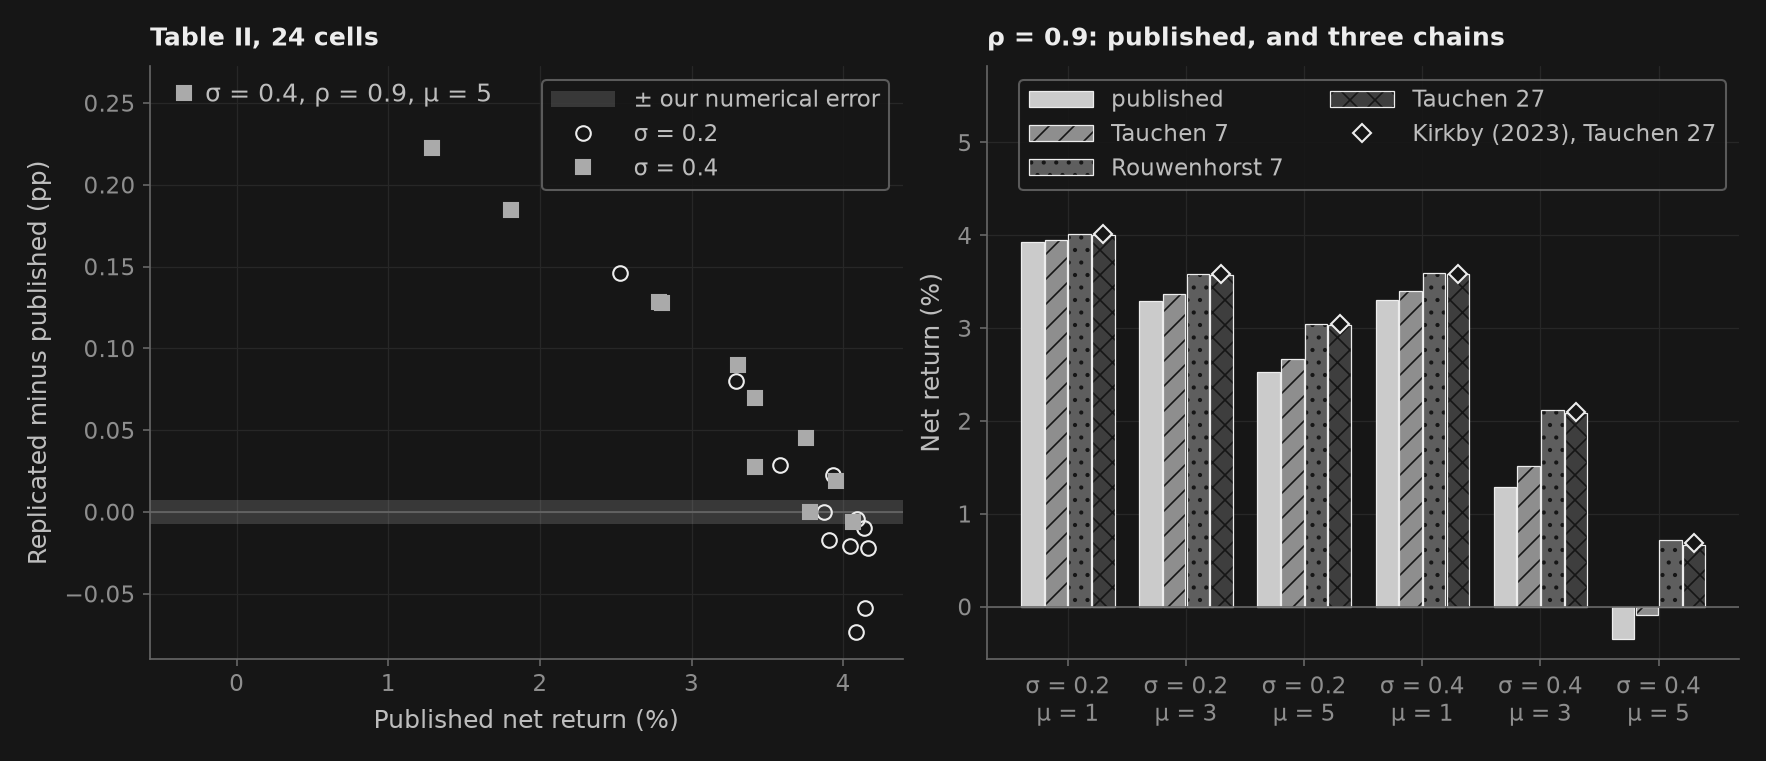

In [5]:
col = _nbstyle.palette(3)
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(11.5, 4.8))
ax1.axhspan(-numerical_error, numerical_error, color=_nbstyle.TINTA, alpha=_nbstyle.BANDA_ALPHA, lw=0,
            label="± our numerical error")
ax1.axhline(0.0, color=_nbstyle.SPINE, lw=0.8)
for sigma, marker, color in ((0.2, "o", col[0]), (0.4, "s", col[1])):
    part = table_ii.xs(sigma, level="sigma")
    ax1.plot(part["r published"], part["gap (pp)"], marker, color=color, mfc="none" if sigma == 0.2 else color,
             ms=7, linestyle="none", label=f"σ = {sigma}")
corner = table_ii.loc[(0.4, 0.9, 5)]
ax1.annotate("σ = 0.4, ρ = 0.9, μ = 5", (corner["r published"], corner["gap (pp)"]), textcoords="offset points",
             xytext=(10, -4), color=_nbstyle.TEXTO)
ax1.set(xlabel="Published net return (%)", ylabel="Replicated minus published (pp)", title="Table II, 24 cells")
ax1.legend(loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
x = np.arange(len(discretization))
names = ["published", "Tauchen 7", "Rouwenhorst 7", "Tauchen 27"]
for k, name in enumerate(names):
    ax2.bar(x + (k - 1.5) * 0.2, discretization[name], width=0.19, color=_nbstyle.BARRA_COLORES[k],
            hatch=_nbstyle.BARRA_HATCH[k], edgecolor=_nbstyle.TINTA, lw=0.6, label=name)
ax2.plot(x + 0.3, discretization["Kirkby, Tauchen 27"], "D", color=_nbstyle.TINTA, mfc=_nbstyle.FONDO, ms=6,
         linestyle="none", label="Kirkby (2023), Tauchen 27")
ax2.axhline(0.0, color=_nbstyle.SPINE, lw=0.8)
ax2.set_xticks(x, [f"σ = {s}\nμ = {m}" for s, m in discretization.index])
ax2.set(ylabel="Net return (%)", title="ρ = 0.9: published, and three chains")
ax2.set_ylim(top=1.45 * discretization.to_numpy().max())   # room for the legend above the bars
handles, labels = ax2.get_legend_handles_labels()
order = [labels.index(name) for name in names + ["Kirkby (2023), Tauchen 27"]]   # bars first, then the marker
ax2.legend([handles[i] for i in order], [labels[i] for i in order], loc="upper right", ncol=2, frameon=True,
           facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)

### 4. Huggett's Tables 1 and 2

Huggett's economy has six periods a year, $\beta=0.99322$, endowments $1.0$ and $0.1$, and credit limits from $-2$ to $-8$ in bond units (one year's average endowment is about $5.3$). The price $q$ is per model period; annual rates are $q^{-6}-1$. The tables are keyed on risk aversion $\mu$, Huggett's $\sigma$. Huggett stopped his price search when "excess demand for credit balances is within 0.0025 units of zero", adding that "with this criterion, interest rates that are approximately market clearing vary by less than a tenth of one percent" (p. 962). His household grid had "between 150 and 350 evenly spaced gridpoints", 0.03 to 0.1 units apart (p. 961). The code evaluates our excess demand at each printed price and sets our prices beside Kirkby's. For the cell with the largest gap, `VFIProblem` solves the same economy by discrete value function iteration on a uniform grid about as fine as Huggett's finest: an internal check by a different method.

In [6]:
huggett = []
for (mu, limit), (r_pub, _, q_pub) in HUGGETT_TABLES.items():
    q = huggett_price(mu, limit)
    huggett.append({"mu": mu, "credit limit": limit, "q published": q_pub, "q replicated": q,
                    "q Kirkby": KIRKBY_HUGGETT_Q[(mu, limit)], "r published": r_pub, "r replicated": annual_rate(q),
                    "balance at published q": huggett_balance(q_pub, mu, limit)})
huggett = pd.DataFrame(huggett).set_index(["mu", "credit limit"])
huggett["balance / 0.0025"] = huggett["balance at published q"].abs() / 0.0025
print(huggett.round(5).to_string())
rate_gaps = (huggett["r replicated"] - huggett["r published"]).abs()
print(f"At the printed prices our excess demand for credit balances is {huggett['balance / 0.0025'].min():.0f} to "
      f"{huggett['balance / 0.0025'].max():.0f} times Huggett's criterion, and the annual rates differ by "
      f"{rate_gaps.min():.2f} to {rate_gaps.max():.2f} pp")


def huggett_price_vfi(mu, limit, bracket, n_a=600, a_max=12.0):
    """The same equilibrium by discrete value function iteration on a uniform grid."""
    a_grid = np.linspace(limit, a_max, n_a)

    def payoff(ap, a, z, q, xp=np):
        c = a + xp.exp(z) - q * ap
        return xp.where(c > 0.0, (xp.maximum(c, 1e-12) ** (1.0 - mu) - 1.0) / (1.0 - mu), -np.inf)

    def mean_balance(q):
        problem = VFIProblem(a_grid=a_grid, z_grid=np.log(E_H), P_z=P_H, return_fn=payoff, beta=BETA_H,
                             params={"q": q}, options={"tol": 1e-9, "n_howard": 60, "max_iter": 20_000})
        dist = problem.stationary_distribution(problem.solve("numpy"))
        return float(np.sum(dist * a_grid[:, None]))

    return brentq(mean_balance, *bracket, xtol=1e-6), a_grid[1] - a_grid[0]


gaps_q = (huggett["q replicated"] - huggett["q published"]).abs()
worst = gaps_q.idxmax()
q_egm = huggett.loc[worst, "q replicated"]
q_vfi, vfi_spacing = huggett_price_vfi(*worst, bracket=(q_egm - 0.005, q_egm + 0.005))  # needs only a sign change
vfi_gap = abs(q_vfi - q_egm)
print(f"Largest gap at mu = {worst[0]}, limit = {worst[1]}: EGM q = {q_egm:.5f}, discrete VFI q = {q_vfi:.5f} "
      f"(grid spacing {vfi_spacing:.3f}), published {huggett.loc[worst, 'q published']}")

kirkby_q_gap = (huggett["q replicated"] - huggett["q Kirkby"]).abs()
kirkby_inner = kirkby_q_gap.drop(index=-8, level="credit limit").max()
kirkby_outer = kirkby_q_gap.xs(-8, level="credit limit").max()
truncated = {mu: huggett_price(mu, -8, x_max=KIRKBY_A_TOP * huggett.loc[(mu, -8), "q replicated"]) -
             huggett.loc[(mu, -8), "q replicated"] for mu in (1.5, 3.0)}
print(f"Our prices minus Kirkby's: at most {kirkby_inner:.1e} for limits -2 to -6 (his grid step plus rounding "
      f"{KIRKBY_Q_STEP + 5e-5:.1e}), {kirkby_outer:.1e} at -8; cutting our grid at a = {KIRKBY_A_TOP:.0f}, where "
      f"his stops, moves the -8 prices by {', '.join(f'{v:+.1e}' for v in truncated.values())}")

r_rep = huggett["r replicated"].unstack("credit limit")
r_pub = huggett["r published"].unstack("credit limit")
huggett_violations = (int(not (np.diff(r_rep.to_numpy(), axis=1) < 0).all()) + int(not (np.diff(r_pub.to_numpy(), axis=1) < 0).all())
                      + int(not (r_rep.loc[3.0] < r_rep.loc[1.5]).all()) + int(not (r_pub.loc[3.0] < r_pub.loc[1.5]).all())
                      + int(not (r_pub < annual_rate(BETA_H)).all().all()))
n_huggett_beyond = int((gaps_q > 5e-5 + vfi_gap).sum())
record("Huggett: orderings in the limit and mu violated, or published r >= 1/beta - 1", huggett_violations, 0,
       "qualitative", "published")
record("Huggett: largest |q - published|", gaps_q.max(), "reported", "differs", "published")
record("Huggett: smallest excess demand at a published price / 0.0025", huggett["balance / 0.0025"].min(),
       "reported", "not the tolerance", "published")
record("Kirkby (VFI Toolkit): |q - his q|, limits -2 to -6, 6 cells", kirkby_inner, KIRKBY_Q_STEP + 5e-5,
       "accuracy", "Kirkby")
record("Kirkby (VFI Toolkit): |q - his q| at limit -8, 2 cells", kirkby_outer, "reported", "his grid stops at a = 4",
       "Kirkby")
record("Discrete VFI minus EGM price, worst cell", vfi_gap, 1e-4, "accuracy", "internal")
assert huggett_violations == 0 and vfi_gap < 1e-4 and kirkby_inner <= KIRKBY_Q_STEP + 5e-5
assert huggett["balance / 0.0025"].min() > 1.0 and rate_gaps.min() > 0.1 and n_huggett_beyond == 8

                  q published  q replicated  q Kirkby  r published  r replicated  balance at published q  balance / 0.0025
mu  credit limit                                                                                                          
1.5 -2                 1.0124       1.01280    1.0128         -7.1      -7.34932                 0.02480           9.92144
    -4                 0.9962       0.99801    0.9981          2.3       1.19994                 0.87812         351.24783
    -6                 0.9944       0.99504    0.9950          3.4       3.03074                 1.09866         439.46570
    -8                 0.9935       0.99411    0.9938          4.0       3.60514                 4.97606        1990.42583
3.0 -2                 1.0448       1.04596    1.0459        -23.0     -23.63320                 0.03205          12.82000
    -4                 1.0045       1.00745    1.0075         -2.6      -4.35464                 0.45082         180.32667
    -6          

Largest gap at mu = 3.0, limit = -4: EGM q = 1.00745, discrete VFI q = 1.00746 (grid spacing 0.027), published 1.0045


Our prices minus Kirkby's: at most 8.6e-05 for limits -2 to -6 (his grid step plus rounding 1.8e-04), 3.5e-04 at -8; cutting our grid at a = 4, where his stops, moves the -8 prices by -8.6e-05, -1.1e-04


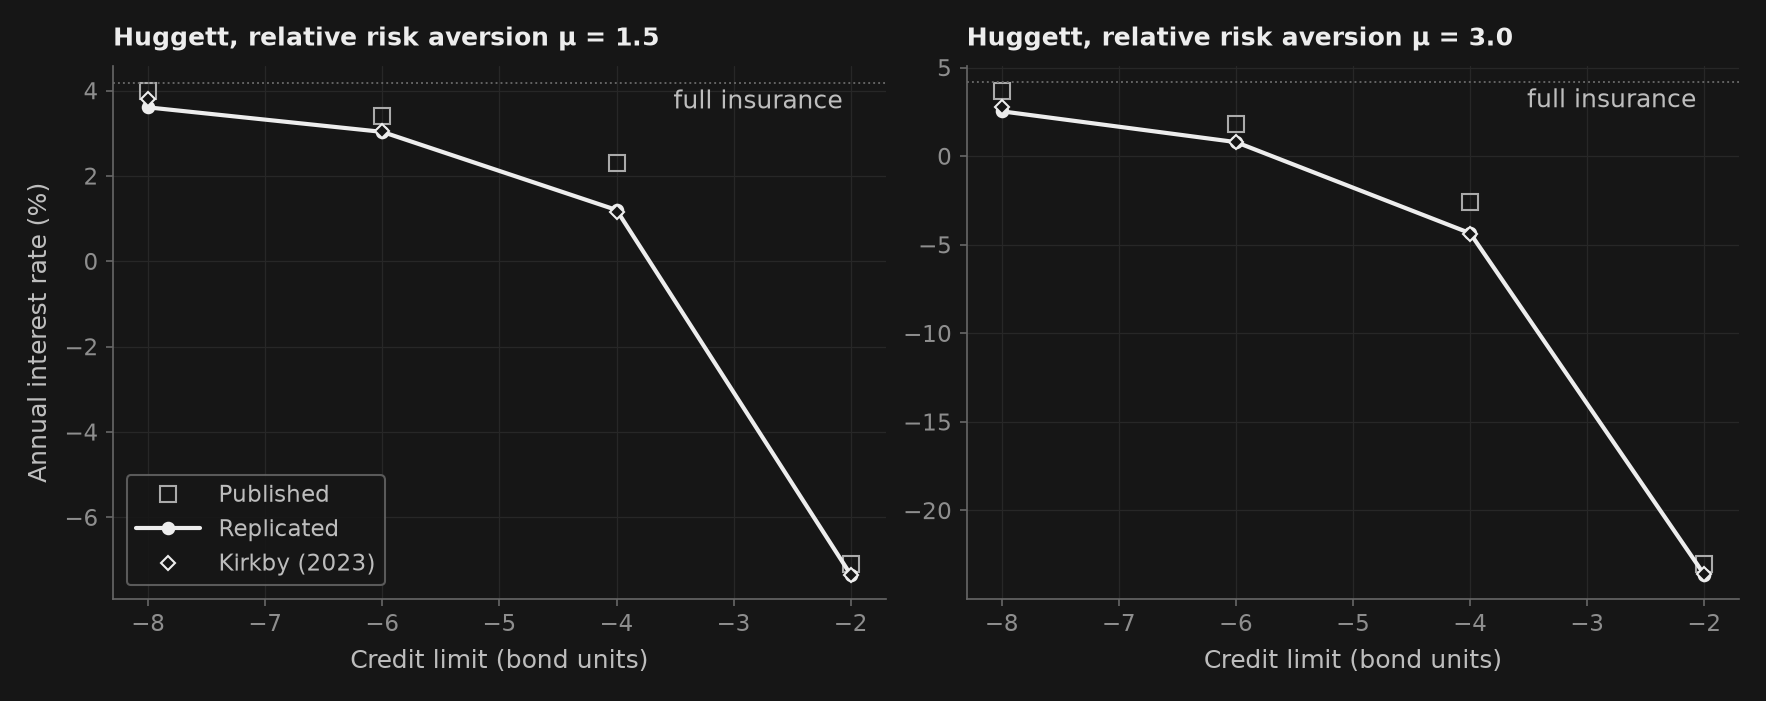

In [7]:
fig, axes = _nbstyle.figura(1, 2, figsize=(11.5, 4.4))
kirkby_r = huggett["q Kirkby"].map(annual_rate).unstack("credit limit")
for ax, mu in zip(axes, (1.5, 3.0)):
    limits = r_rep.columns.to_numpy()
    ax.plot(limits, r_pub.loc[mu], "s", color=col[1], ms=8, mfc="none", label="Published")
    ax.plot(limits, r_rep.loc[mu], color=col[0], lw=2.0, marker="o", label="Replicated")
    ax.plot(limits, kirkby_r.loc[mu], "D", color=_nbstyle.TINTA, mfc=_nbstyle.FONDO, ms=5, linestyle="none",
            label="Kirkby (2023)")
    ax.axhline(annual_rate(BETA_H), color=_nbstyle.SPINE, lw=0.9, linestyle=":")
    ax.annotate("full insurance", (limits.max(), annual_rate(BETA_H)), textcoords="offset points", xytext=(-4, -12),
                ha="right", color=_nbstyle.TEXTO)
    ax.set(xlabel="Credit limit (bond units)", title=f"Huggett, relative risk aversion μ = {mu}")
axes[0].set_ylabel("Annual interest rate (%)")
axes[0].legend(loc="lower left", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)

### Replication scorecard

Each row names its oracle ("published" and "Kirkby" are independent of puremacro; "internal" rows are our own accuracy checks) and gives the measured value and the bound it had to meet, or "reported" where the size of a difference is the finding. The verdict lines are computed from the rows.

In [8]:
scorecard = pd.DataFrame(checks)
print(scorecard.to_string(index=False, formatters={"measured": "{:.2e}".format}))
bounded = scorecard[scorecard["bound"] != "reported"]
assert (bounded["measured"] <= bounded["bound"].astype(float)).all()
huggett_wedge = annual_rate(BETA_H) - huggett["r replicated"]
print(f"\n{len(bounded)} checks with a bound pass. Table I is reproduced exactly and every published ordering holds. "
      f"{n_beyond} of 24 Aiyagari rates differ from the printed ones by more than our numerical error (by up to "
      f"{largest_gap:.2f} pp), and all {n_huggett_beyond} Huggett prices differ, by up to {gaps_q.max():.4f}. "
      f"Kirkby's independent solutions agree with ours to {kirkby_r_gap:.3f} pp and {kirkby_inner:.1e} in price. "
      f"Changing the chain moves Aiyagari's rates by up to {shift:.2f} pp.")
print(f"How far below the rate of time preference? Aiyagari, on his chain: {wedge_rep.min():.2f} to {wedge_rep.max():.2f} "
      f"pp below {RTP:.2f}%, and {RTP - corner_27:.2f} pp at the corner on the 27-state chain. "
      f"Huggett: {huggett_wedge.min():.2f} to {huggett_wedge.max():.2f} pp a year below {annual_rate(BETA_H):.2f}%.")

                                                                                      result    oracle measured     bound                 verdict
               Transcription: Aiyagari s = delta*alpha/(r + delta), gap / rounding allowance published 9.60e-01       1.0              consistent
                               Transcription: Huggett r = q^-6 - 1, gap / rounding allowance published 7.33e-01       1.0              consistent
                                                Aiyagari Table I: cells not reproduced, of 8 published 0.00e+00         0                   exact
Aiyagari Table II: orderings in sigma, rho, mu violated (of 3), or published r >= 1/beta - 1 published 0.00e+00         0             qualitative
                     Aiyagari Table II: cells whose |gap| exceeds our numerical error, of 24 published 2.00e+01  reported                 differs
                                              Aiyagari Table II: largest |r - published|, pp published 2.56e-01  reported   

## Read the output

**The answer to the question.** On Aiyagari's own chain, uninsurable risk puts the interest rate 0.02 to 4.26 pp below the rate of time preference of 4.17%, from the calmest economy to the riskiest, where the replicated rate is slightly negative ($-0.0897\%$). On a finer chain the riskiest wedge is 3.51 pp. In Huggett's economies, where households can only lend to each other, the annual rate lies 0.56 to 27.80 pp below 4.17%, and the tighter the credit limit, the larger the wedge.

**Table I** is reproduced cell by cell by the chain Aiyagari documents, and grids of width 2.0, 2.5 and 3.5 fail. The extra columns show what the table itself only implies: the chain's level c.v. over the process's is 1.039 at $\rho=0$ and 1.172 at $\rho=0.9$, for both values of $\sigma$.

**Table II's structure** is reproduced. The rate falls with the size and persistence of risk and with risk aversion in every one of the 24 cells, and the saving rates follow. **Most of its decimals are not.** 20 of the 24 gaps exceed our numerical error of 0.0074 pp, and 8 exceed ten times it. The error has a sign: coarse household grids understate the rate. The four cells within the error include $(0.4, 0, 3)$, which matches all four printed decimals. The gaps are not scattered. They are negative in the calm cells, positive and growing toward the high-risk corner, and they track the size of the precautionary effect (correlation 0.93). Aiyagari's working paper names two features of his method that could leave such a pattern, and neither is tested here: the asset demand is a piecewise-linear function on 25 sub-intervals (p. 27), and mean assets come from a single simulated series of 10,000 draws (pp. 27-28), although his footnote 39 reports that 20,000 draws changed the results only very slightly. The stretch exercise below measures the sampling error. The packaged `solve_aiyagari_continuous`, a separately coded implementation of the same method, reproduces our three lowest rates to 0.0036 pp or better.

**The hero figure makes the second lesson visible.** At $\rho=0.9$, replacing the seven-state Tauchen chain by the Rouwenhorst chain, which matches the mean, variance and autocorrelation of log income exactly, moves the equilibrium rate by up to 0.81 pp, more than three times the largest gap between the replication and the paper. Seven Rouwenhorst states land within 0.0612 pp of the 27-state Tauchen chain: close enough to see the chain effect, not close enough to pin the corner's decimals. On the 27-state chain our rates agree with Kirkby's independent solutions to 0.019 pp. His replication study reports that the bottom-right corner of Aiyagari's Table II "contained numerical error" (Kirkby 2023, footnote 3), and he gets 0.6806% there against the printed $-0.3456\%$. Most of that difference is the chain, in line with his finding that the discretization of shocks has "a large and unappreciated influence on results": on Aiyagari's seven-state chain our corner is $-0.0897\%$, on the 27-state chain it is 0.6612%. So the high-persistence corner of Table II describes the discretized chain at least as much as the AR(1) process. The qualitative conclusion, that uninsurable risk lowers the interest rate and raises saving, survives every one of these changes.

**Huggett's gaps are unexplained.** His tolerance cannot account for them: at the printed prices our excess demand for credit balances is 10 to 1990 times his 0.0025 criterion, and the annual rates differ by 0.25 to 1.75 pp, where he says the criterion keeps them within a tenth of a point. Our method and grid are not the cause either. Kirkby's independent solution lands on our prices, within 8.6e-05 for the limits $-2$ to $-6$, and discrete value function iteration on a grid 0.027 apart, close to Huggett's finest, reproduces our worst-cell price to 1.02e-05. At the limit $-8$ Kirkby's prices are up to 3.5e-04 below ours. His asset grid stops at $a=4$, and cutting ours there moves our prices toward his by 8.6e-05 and 1.1e-04, less than a third of the difference. Huggett's figure shows the borrowing-limit mechanism all the same: tighter credit limits lower the risk-free rate, and higher risk aversion lowers it further. Because annual rates compound six model periods, small differences in the per-period price become visible differences in the annual rate.

## Your turn

The cell re-solves the Table II cell $\sigma=0.4$, $\rho=0.9$, $\mu=3$ on a chain you choose and compares the chain with the log-normal process it approximates and with Table I. Its assertions check that the capital market clears at the returned rate, that the asset grid does not cut off the wealth distribution and, for Rouwenhorst, that the log moments are exact while the level c.v. stays below the process's; each can fail. The bound $r<1/\beta-1$ is not asserted: the root-finder's bracket imposes it, and a chain with no equilibrium inside the bracket makes `brentq` raise.

1. **Basic: the chain against the process.** Predict first: does a seven-state chain overstate or understate the process's level c.v.? Run the default, then set `chain = "rouwenhorst"` and try `n_states` = 3, 7 and 25. The log s.d. and autocorrelation are exact at every $N$; why does the level c.v. still move with $N$, and from which side does it approach the closed form? By how much does the seven-state Tauchen chain behind Table I's 0.49 overstate the process, and what does that imply for Table II's $\rho=0.9$ row? Why would Tauchen at a fixed width stop converging as $N$ grows very large?
2. **Intermediate: persistence versus dispersion.** Set `chain = "tauchen"`, `n_states = 3` and `grid_width = 3.5`, and print `np.diag(P)`. The chain's c.v. is larger than the default's, so why is its rate much higher? In a new cell, compare two designs with `rouwenhorst(7, rho, sigma_eps)` and `aiyagari_rate(..., 3)`: hold the unconditional s.d. at 0.4 for $\rho\in\{0.6, 0.9, 0.99\}$, then hold the innovation s.d. at $0.4\sqrt{1-0.81}$ for $\rho\in\{0.6, 0.9, 0.97\}$. Which design do Table II's $\rho$ columns follow, and which does the three-state chain resemble? Your answers should pass: at the three-state setting `cv > 0.4885`, `ac > 0.999` and `r_custom > 3.5`; in the first design the rate at 0.9 is below both others; in the second it falls with $\rho$ and is negative at 0.97.
3. **Intermediate: how loose must credit be for a positive risk-free rate?** Solve Huggett's economy with `huggett_price` and `annual_rate` at credit limits $-2, -3, -4, -6, -8, -10$ for $\mu=1.5$ and $3.0$ (12 solves, under half a second each). Check that the four published limits lie on the curves of section 4, then find for each $\mu$ the limit at which the annual rate crosses zero. Why does looser credit raise the rate toward, but never up to, `annual_rate(BETA_H)`, and why does the more prudent household need more borrowing room before the rate turns positive? Your answers should pass: for each $\mu$ the rate rises as the limit loosens and stays below `annual_rate(BETA_H)`; the zero lies between $-3$ and $-4$ at $\mu=1.5$ and between $-4$ and $-6$ at $\mu=3$; the rate at $\mu=3$ is below the rate at $\mu=1.5$ at every limit.
4. **Stretch: an error budget for the corner gap.** Aiyagari simulates the chain once for 10,000 draws, feeds them through the asset demand and takes the sample mean as $Ea$ (WP 502, pp. 27-28; footnote 39 reports only very minor changes at 20,000 draws). Test this at the corner $\sigma=0.4$, $\rho=0.9$, $\mu=5$. (a) Sweep `grid_width` from 2.90 to 3.10 in steps of 0.005, keep the widths whose seven-state chain reproduces all eight Table I cells, and re-solve the corner at both ends. (b) At our equilibrium rate, rebuild the policy with `solve_egm` on the grids of `aiyagari_market`, simulate 400 independent households for 10,000 and for 20,000 periods, and turn each time-average error into a rate error with the slope of excess capital supply (a centred difference of `aiyagari_market` with $h=2\times10^{-4}$). Compare the s.d. with the gap, the chain spread and our grid error. Why does it fall like $1/\sqrt{T}$, and why do persistent assets make 10,000 draws worth far fewer independent observations? (c) Could independent, mean-zero sampling errors produce gaps that are negative in the calmest cells and grow positive toward the corner? Your answers should pass: the identified widths straddle 3.0 in a band narrower than 0.1; the corner spread across them is below 0.1 pp and below a third of the gap; the s.d. at 20,000 draws is 0.6 to 0.85 times the s.d. at 10,000; the gap is within two 10,000-draw s.d.

In [9]:
chain = "tauchen"   # ← change this: "tauchen" or "rouwenhorst"
n_states = 7        # ← change this: number of Markov states, 3 to 25
grid_width = 3.0    # ← change this: Tauchen half-width in unconditional s.d., 1.5 to 3.5 (Rouwenhorst ignores it)
assert chain in ("tauchen", "rouwenhorst") and 3 <= n_states <= 25 and 1.5 <= grid_width <= 3.5
sigma_u, rho_u, mu_u = 0.4, 0.9, 3               # the Table II cell: unconditional s.d., persistence, risk aversion
sigma_eps = sigma_u * np.sqrt(1.0 - rho_u**2)
if chain == "tauchen":
    log_grid, P = tauchen(n_states, rho_u, sigma_eps, m=grid_width)
else:
    log_grid, P = rouwenhorst(n_states, rho_u, sigma_eps)
log_sd, log_ac = log_moments(log_grid, P)
cv, ac = level_moments(log_grid, P)
cv_true = np.sqrt(np.exp(sigma_u**2) - 1.0)                                     # log-normal AR(1), closed form
ac_true = (np.exp(rho_u * sigma_u**2) - 1.0) / (np.exp(sigma_u**2) - 1.0)
r_custom = 100.0 * aiyagari_rate(log_grid, P, mu_u)
excess, demand, top_mass = aiyagari_market(log_grid, P, mu_u, r_custom / 100.0)
cv_pub, ac_pub = AIYAGARI_TABLE_I[(sigma_u, rho_u)]
width_note = f", width {grid_width}" if chain == "tauchen" else ""
print(f"{chain}, {n_states} states{width_note}: log s.d. {log_sd:.4f} and autocorrelation {log_ac:.4f} "
      f"(process {sigma_u}/{rho_u}); level c.v. {cv:.4f} and autocorrelation {ac:.4f} "
      f"(process {cv_true:.4f}/{ac_true:.4f}, Table I {cv_pub}/{ac_pub})")
print(f"Equilibrium net return {r_custom:.4f}% (published {AIYAGARI_TABLE_II[(sigma_u, rho_u, mu_u)][0]:.4f}%); "
      f"excess capital {excess / demand:.1e} of demand; mass in the top tenth of the asset grid {top_mass:.1e}")
assert abs(excess) < 1e-6 * demand            # the capital market clears at the rate brentq returned
assert top_mass < 1e-6                         # a_max = 200 does not cut off the wealth distribution
if chain == "rouwenhorst":                     # exact log moments at any N, on a binomial rather than normal grid
    assert abs(log_sd - sigma_u) < 1e-12 and abs(log_ac - rho_u) < 1e-12 and cv < cv_true

tauchen, 7 states, width 3.0: log s.d. 0.4683 and autocorrelation 0.9016 (process 0.4/0.9); level c.v. 0.4885 and autocorrelation 0.8913 (process 0.4165/0.8926, Table I 0.49/0.89)
Equilibrium net return 1.5118% (published 1.2894%); excess capital -2.4e-14 of demand; mass in the top tenth of the asset grid 2.6e-28


## How comprehensive is this?

Notebook 01 introduces the Aiyagari and Huggett economies with the discrete-grid solver, 23 adds endogenous labor supply, 52 computes transitions after an unexpected shock, and 56 solves the continuous-time version. Notebook 01's `aiyagari_steady_state` takes the *innovation* s.d.: to reproduce a Table II cell with it, pass `sigma=σ*np.sqrt(1-ρ**2)`, `rho=ρ`, `n_z=7` and `gamma=μ`, widen `r_bracket` for cells outside its default range (0.5% to 0.2 pp below $1/\beta-1$), and check that `a_max` does not cut off the wealth distribution. `docs/vfi_continuous_equilibrium.md` documents `continuous_stationary_distribution` and `solve_aiyagari_continuous`, which packages the same three steps; section 2 runs it with `a_max=200` and `n_a=800`, and its `converged` flag certifies the household fixed point, the distribution and market clearing. This notebook replicates stationary equilibria only and does not check the papers' distributional statistics. It leaves two things open: the source of Huggett's printed prices, which neither his tolerance nor a grid like his accounts for, and the source of the pattern in Aiyagari's decimals, whose candidates are named from his text but not tested here.